# Assignment 4
### Do three of six.


Sophie Kim

### Exercise 1: Contingent Comparisons
- Load the Minnesota use of force data.
- Bootstrap the proportion of missing values for `subject_injury` for each race, and plot the results with grouped KDE and ECDF plots
- Describe what you see. When we consider second order uncertainty, how similar or different are the sampling distributions of these proportions? 

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/week 3/data/mn_police_use_of_force.csv")

In [16]:
df

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12920,2021/08/30 21:38:46,Assault in Progress,Yes,ASLT5,NaN,Bodily Force,Joint Lock,White,Female,69.0,NaN,1,Loring Park
12921,2021/08/30 22:32:22,Unwanted Person,Yes,CIC,NaN,Bodily Force,Joint Lock,NaN,NaN,NaN,NaN,1,Cedar Riverside
12922,2021/08/31 12:03:08,Overdose w/All,Yes,FORCE,NaN,Bodily Force,Body Weight Pin,Black,Male,NaN,NaN,3,Seward
12923,2021/08/31 12:52:52,Attempt Pick-Up,No,WT,NaN,Bodily Force,Body Weight Pin,Black,Male,31.0,NaN,4,Camden Industrial


In [60]:
df['injury_na'] = df['subject_injury'].isna()

In [81]:
pd.crosstab(df['injury_na'], df['race'])

race,Asian,Black,Native American,Other / Mixed Race,Pacific Islander,White
injury_na,,,,,,
False,47,1842,220,121,0,771
True,82,5806,564,84,6,2358


In [61]:
def stat(x):
    stat = np.mean(x)
    return stat

In [79]:
def simulate(var, df, fcn, S=1000, plot=True):
    results = []

    for race in df['race'].dropna().unique():
        x = df.loc[df['race'] == race, var]

        estimates = []
        for s in range(S):
            x_s = x.sample(frac=1.0, replace=True)
            estimates.append(fcn(x_s))  

        estimates = np.array(estimates) 

       
        results.extend([{"race": race, "proportion missing": val} for val in estimates])

    df_boot = pd.DataFrame(results)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        sns.kdeplot(data=df_boot, x="proportion missing", hue="race", ax=axes[0])
        axes[0].set_title("KDE of Bootstrapped Proportions")

        sns.ecdfplot(data=df_boot, x="proportion missing", hue="race", ax=axes[1])
        axes[1].set_title("ECDF of Bootstrapped Proportions")

        plt.show()

    return df_boot


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_59849/1307961800.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_boot, x="proportion missing", hue="race", ax=axes[0])


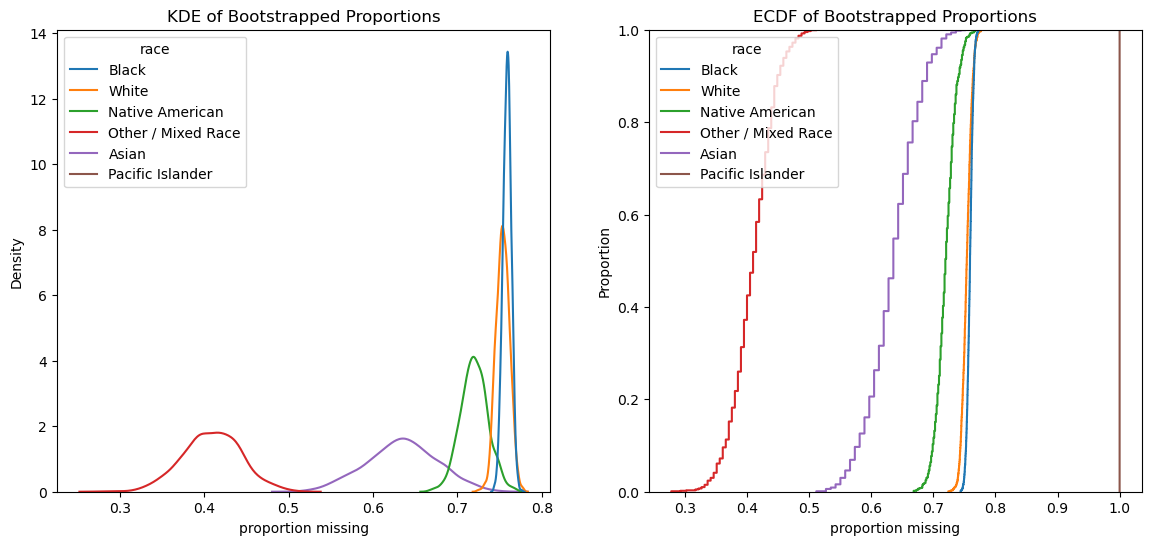

,race,proportion missing
0,Black,0.757714
1,Black,0.753269
2,Black,0.757191
3,Black,0.763206
4,Black,0.762683
...,...,...
5995,Pacific Islander,1.000000
5996,Pacific Islander,1.000000
5997,Pacific Islander,1.000000
5998,Pacific Islander,1.000000


In [80]:
var = 'injury_na'
simulate(var, df, stat)

*In the KDE plot, black and white races have the highest proportion of missing subject data. Because their peaks are so high (meaning higher density), black and white races also have low variation in the estimates found from bootstrapping. In other words, black and white races have low second order uncertainty. Native American, Asian, Other/Mixed Race had more variation, in that order (aka higher second order uncertainty). Pacific Islander isn't visible on the KDE plot since there were so little observations compared to the other races.*

*In the ECDF plot, the little variance of Black and White races is reflected in the steepr curves. Here, you can see that the Pacfic Islander line is a straight, vertical line due to the lack of variance in all of the Pacific Islander obsservations. The relatively flatter curves of Native American, Asian, Other/Mixed Race reflect the higher variation compared to Black, White, and Pacific Islander.*

### Exercise 2: Invitation to Inference
- Run the simulation code line by line and comment what each line is doing, or write your own code to do the resampling
- Open the NHANES or Ames prices or College Completion data
- Use the above function `simulate` to get a sample of estimates for your statistic and your data
- Create a new function, `interval(L,H,estimates)`, that computes the $L$-th and $H$-th quantiles for your estimates, $H>L$
- If $L=.05$ and $H=.95$, this is a **90-percent confidence interval**: "For our statistic, this interval captures the true value of the population parameter 90 percent of the time. (We are 90% **confident** that it includes the true value of the parameter, but the probability that the true parameter lies in this interval is 0 or 1.)"
- We will spend much more time on this later in class, but for people who have done hypothesis testing before, you now know how to do it directly from the data: No central limit theorem required.

In [84]:
def stat(x):
    stat = np.mean(x)
    return stat

In [ ]:
def simulate(var, df, fcn, S=1000, plot=True): 
    # S variable is the amount of times you are bootstrapping
    # var is column from df you want to use
    # fcn computes whatever statistic (see stat function)
    ''' Bootstrap simulation code. '''    
    x = df[var] # getting variable 

    estimates = [] # start empty list to store bootstrapping results
    for s in range(S): # drawing 1000 estimates from the mean 
        x_s = x.sample(frac=1.0,replace=True) #frac --> 100% of sample (1.0) & replace=True means sampling with replacement
            # this ^^ is basically saying to make a new sample with the same number of rows 
            # as the original sample size but replace the values when you draw one
        stat_s = fcn(x_s) # applies statistic function to bootstrap sample
        estimates.append(stat_s) # stores statistic in estimates list 
    estimates = np.array(estimates) # convert estimates list to numpy array

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 3 side by side plots
        sns.kdeplot(x, ax = axes[0]).set(title='KDE of Underlying Data') # KDE plot of orginal data
        sns.kdeplot(estimates, ax = axes[1]).set(title='KDE of Computed Statistics') # KDE plot of bootstrap statistics
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--')
        sns.ecdfplot(estimates, ax = axes[2]).set(title='ECDF of Computed Statistics') # ECDF plot of bootstrap statistics
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--')
        plt.show() # show plots
        print(f'Variance of estimates is: {np.var(estimates)}') # prints variance of bootstrap estimates 
        
    return estimates


In [ ]:
df2 = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/week 3/data/nhanes_data_17_18.csv")
print(df2.columns.to_list())


['SEQN', 'GeneralHealthCondition', 'EverBreastfedOrFedBreastmilk', 'AgeStoppedBreastfeedingdays', 'AgeFirstFedFormuladays', 'AgeStoppedReceivingFormuladays', 'AgeStartedOtherFoodbeverage', 'AgeFirstFedMilkdays', 'TypeOfMilkFirstFedWholeMilk', 'TypeOfMilkFirstFed2Milk', 'TypeOfMilkFirstFed1Milk', 'TypeOfMilkFirstFedFatFreeMilk', 'TypeOfMilkFirstFedSoyMilk', 'TypeOfMilkFirstFedOther', 'HowHealthyIsTheDiet', 'Past30DayMilkProductConsumption', 'YouDrinkWholeOrRegularMilk', 'YouDrink2FatMilk', 'YouDrink1FatMilk', 'YouDrinkFatFreeskimMilk', 'YouDrinkSoyMilk', 'YouDrinkAnotherTypeOfMilk', 'RegularMilkUse5TimesPerWeek', 'HowOftenDrankMilkAge512', 'HowOftenDrankMilkAge1317', 'HowOftenDrankMilkAge1835', 'CommunitygovernmentMealsDelivered', 'EatMealsAtCommunityseniorCenter', 'AttendKindergartenThruHighSchool', 'SchoolServesSchoolLunches', 'OfTimesweekGetSchoolLunch', 'SchoolLunchFreeReducedOrFullPrice', 'SchoolServeCompleteBreakfastEachDay', 'OfTimesweekGetSchoolBreakfast', 'SchoolBreakfastFreere

/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_59849/4094155603.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/week 3/data/nhanes_data_17_18.csv")


In [83]:
df2

,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,102952.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0,0.0,Never
8362,102953.0,Fair or,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,65.0,218.0,0.0,Never
8363,102954.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,66.0,150.0,0.0,Never
8364,102955.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


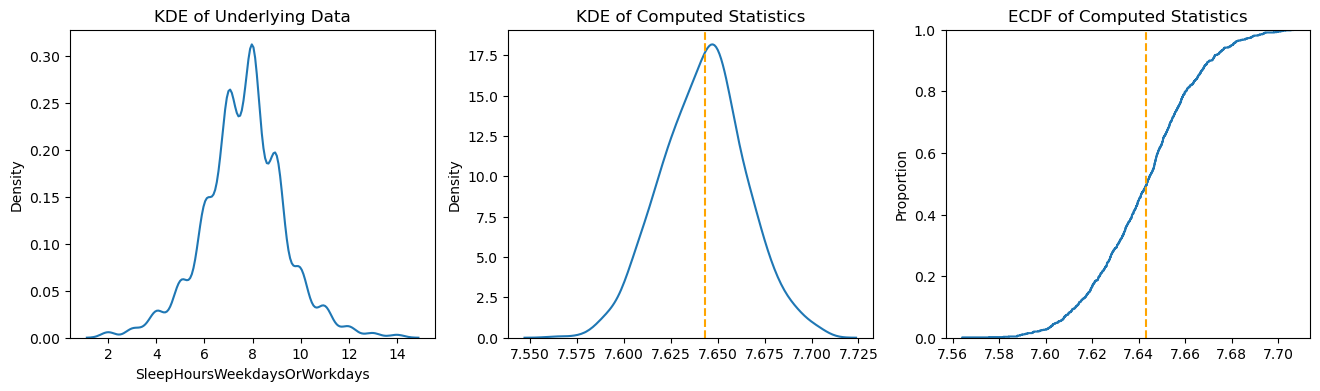

Variance of estimates is: 0.0005064835902864775


In [97]:
var = 'SleepHoursWeekdaysOrWorkdays'
estimates = simulate(var, df2, stat)

In [100]:
def interval(L, H, estimates, plot=True):
    qL = np.quantile(estimates, L)
    qH = np.quantile(estimates, H)

    if plot: 
        sns.kdeplot(estimates)
        plt.axvline(x=qL, color='orange', linestyle='--')
        plt.axvline(x=qH, color='orange', linestyle='--')
        print(f'interval lower bound: {qL} \ninterval upper bound: {qH}')
    return qL, qH

interval lower bound: 7.60532222136652 
interval upper bound: 7.679914358508107


(np.float64(7.60532222136652), np.float64(7.679914358508107))

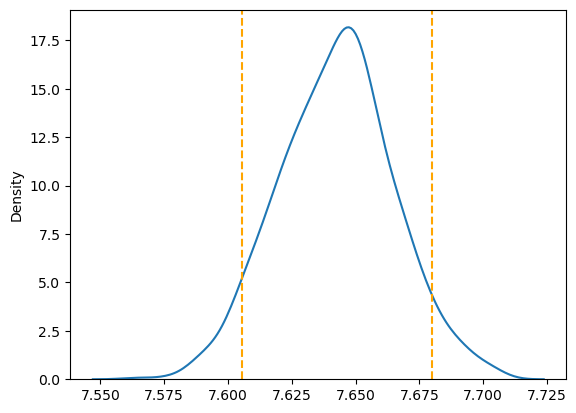

In [101]:
interval(.05, .95, estimates)

### Exercise 3: Intro to A/B Testing
- Go here, and read about this study: https://www.clinicaltrials.gov/study/NCT01985360
- Read the Study Overview and explain what the goal of the trial is 
- Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 
- Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise.
- What is the difference in surival rates between the invasive strategy and the conservative strategy?
- Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF
- Is this an effective health intervention? Explain your answer clearly

This would be what CS people call **A/B testing** and everyone else called a **randomized controlled trial**: Using randomized assignment to detect the difference in outcomes between two groups. (We've just done a non-parametric version of a two-sample t-test.)

### Exercise 4: Prediction Uncertainty
- Pick a dataset and two continuous variables.
- Recall the LCLS estimator:
$$
\hat{y}(z) =  \frac{ \frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left( \frac{z - x_i}{h} \right)}{ \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k\left( \frac{z - x_i}{h} \right)}
$$
with the Epanechnikov kernel and the standard plug-in bandwidth for $h$
- Compute and plot this line for 30 bootstrap samples. Notice where there is a lot of variation in the predictions, versus little variation in the predictions.
- Now, for any $z$, we can bootstrap a distribution of predictions using the above formula. Do this at the 25th percentile, median, and 75th percentile of $X$.
- Now, pick a grid for $z$: Obvious choices are all of the unique values in the data, or an equally spaced grid from the minimum value to the maximum value. For each $z$, bootstrap a sample of predictions and compute the .05 and .95 quantiles. Plot these error curves along with your LCLS estimate. Where are your predictions "tight"/reliable? Where are they highly variable/unreliable?

In [ ]:
college = pd.read_csv("/Users/sophiekim/Desktop/msds/ds 5030/github_branching/college_completion.csv")
college

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3793,3793,461528,Grace College of Divinity,Fayetteville,North Carolina,4-year,Private not-for-profit,Not applicable- not in Carnegie universe,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,43,81,NaN,NaN,12.0
3794,3794,462354,John Paul the Great Catholic University,Escondido,California,4-year,Private not-for-profit,Not applicable- not in Carnegie universe,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,74,81,NaN,NaN,33.0
3795,3795,466921,Chamberlain College of Nursing-Missouri,St. Louis,Missouri,4-year,Private for-profit,Not applicable- not in Carnegie universe,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,20,81,NaN,NaN,8.0
3796,3796,474881,Minneapolis Media Institute,Edina,Minnesota,2-year,Private for-profit,Not applicable- not in Carnegie universe,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5,81,NaN,NaN,145.0


In [ ]:
df = college.loc[:,['aid_value','awards_per_value'] ]
df = df.dropna()
df = df.reset_index()

x = df['awards_per_value']
y = df['aid_value']

In [145]:
def lcls_bootstrap_epanechnikov(x, y, S=30, h=None, plot=True):
   
    n = len(x)
    grid = np.linspace(x.min(), x.max(), 100)  # grid for z values

   
    if h is None:
        iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
        h = 0.9 * min(np.std(x), iqr/1.34) * n**(-0.2)
        print(f"Computed bandwidth h: {h}")


    y_boot = np.full((S, len(grid)), np.nan)  

   
    for s in range(S):
        idx = np.random.choice(n, n, replace=True)
        x_s = x.iloc[idx]
        y_s = y.iloc[idx]

  
        u = (grid.reshape(1, -1) - x_s.to_numpy().reshape(-1, 1)) / h
        K = 0.75 * (1 - u**2) * (np.abs(u) <= 1)

     
        numerator = y_s.to_numpy() @ K
        denominator = np.sum(K, axis=0)

       
        y_est = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator!=0)
        y_boot[s, :] = y_est

    mask = ~np.all(np.isnan(y_boot), axis=0)
    grid_plot = grid[mask]
    y_hat = np.nanmean(y_boot[:, mask], axis=0)
    lower = np.nanpercentile(y_boot[:, mask], 5, axis=0)
    upper = np.nanpercentile(y_boot[:, mask], 95, axis=0)


    z_percentiles = np.percentile(x, [25, 50, 75])
    z_idx = [np.abs(grid_plot - z).argmin() for z in z_percentiles]
    preds_at_percentiles = {}
    for i, z in enumerate(z_percentiles):
        preds = y_boot[:, mask][:, z_idx[i]]
        preds_at_percentiles[z] = {
            "median": np.nanmedian(preds),
            "5%": np.nanpercentile(preds, 5),
            "95%": np.nanpercentile(preds, 95)
        }


    if plot:
        plt.scatter(x, y, alpha=0.3)
        plt.plot(grid_plot, y_hat, color='orange', label='LCLS estimate')
        plt.fill_between(grid_plot, lower, upper, color='orange', alpha=0.2, label='90% CI')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('LCLS with Epanechnikov Kernel and Bootstrap CI')
        plt.legend()
        plt.show()

    return y_hat, grid_plot, lower, upper, preds_at_percentiles


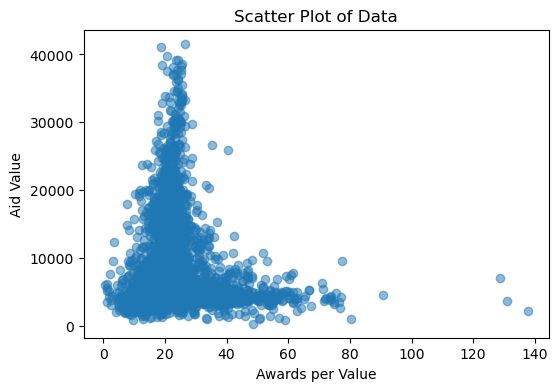

In [146]:
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.5)
plt.xlabel("Awards per Value")
plt.ylabel("Aid Value")
plt.title("Scatter Plot of Data")
plt.show()


Computed bandwidth h: 1.1886046336919212


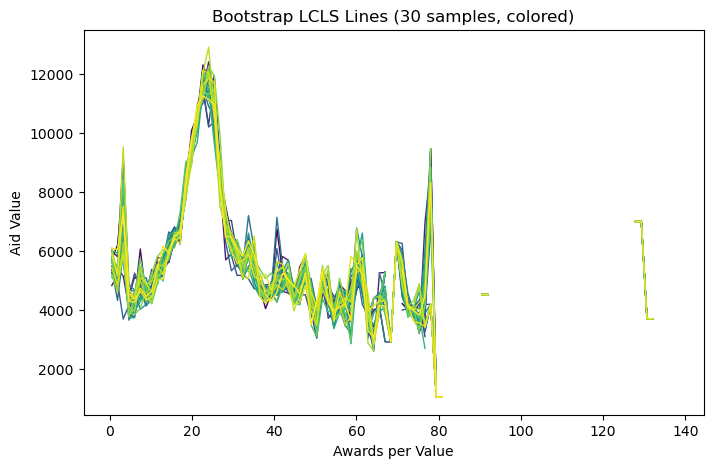

In [147]:

n = len(x)
iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
h = 0.9 * min(np.std(x), iqr / 1.34) * n**(-0.2)
print(f"Computed bandwidth h: {h}")

plt.figure(figsize=(8,5))


colors = plt.cm.viridis(np.linspace(0, 1, 30))

for s in range(30):
    idx = np.random.choice(len(x), len(x), replace=True)
    x_s = x.iloc[idx]
    y_s = y.iloc[idx]


    grid = np.linspace(x.min(), x.max(), 100)
    u = (grid.reshape(1,-1) - x_s.to_numpy().reshape(-1,1)) / h
    K = 0.75 * (1 - u**2) * (np.abs(u) <= 1)
    numerator = y_s.to_numpy() @ K
    denominator = np.sum(K, axis=0)
    y_hat_s = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator!=0)


    plt.plot(grid, y_hat_s, color=colors[s], lw=1)

plt.xlabel("Awards per Value")
plt.ylabel("Aid Value")
plt.title("Bootstrap LCLS Lines (30 samples, colored)")
plt.show()



Computed bandwidth h: 1.1886046336919212


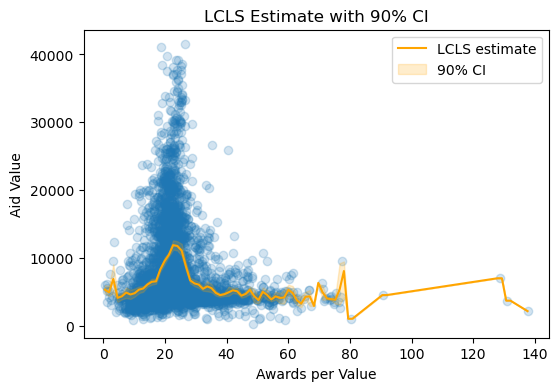

In [143]:
y_hat, grid_plot, lower, upper, percentile_preds = lcls_bootstrap_epanechnikov(x, y, S=30, plot=False)

plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.2)
plt.plot(grid_plot, y_hat, color="orange", label="LCLS estimate")
plt.fill_between(grid_plot, lower, upper, color="orange", alpha=0.2, label="90% CI")
plt.xlabel("Awards per Value")
plt.ylabel("Aid Value")
plt.title("LCLS Estimate with 90% CI")
plt.legend()
plt.show()


In [148]:
def lcls_bootstrap_percentiles_kde(x, y, S=2000, plot=True):

    x25, x50, x75 = np.quantile(x, [0.25, 0.5, 0.75])
    

    est25, est50, est75 = [], [], []
    

    n = len(x)
    iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
    h = 0.9 * min(np.std(x), iqr/1.34) * n**(-0.2)
    

    for s in range(S):
        idx = np.random.choice(n, n, replace=True)
        x_s = x.iloc[idx].to_numpy()
        y_s = y.iloc[idx].to_numpy()
        

        def predict_lcls(z):
            u = (z - x_s) / h
            K = 0.75 * (1 - u**2) * (np.abs(u) <= 1)
            numerator = np.sum(K * y_s)
            denominator = np.sum(K)
            return numerator / denominator if denominator != 0 else np.nan
        

        est25.append(predict_lcls(x25))
        est50.append(predict_lcls(x50))
        est75.append(predict_lcls(x75))
    

    results = {
        "25th": np.array(est25),
        "50th": np.array(est50),
        "75th": np.array(est75)
    }
    

    if plot:
        plt.figure(figsize=(8,5))
        sns.kdeplot(results["25th"], fill=True, label="25th percentile")
        sns.kdeplot(results["50th"], fill=True, label="50th percentile")
        sns.kdeplot(results["75th"], fill=True, label="75th percentile")
        plt.xlabel("Predicted y")
        plt.ylabel("Density")
        plt.title("Bootstrap LCLS Predictions at Percentiles (KDE)")
        plt.legend()
        plt.show()
    
    return results



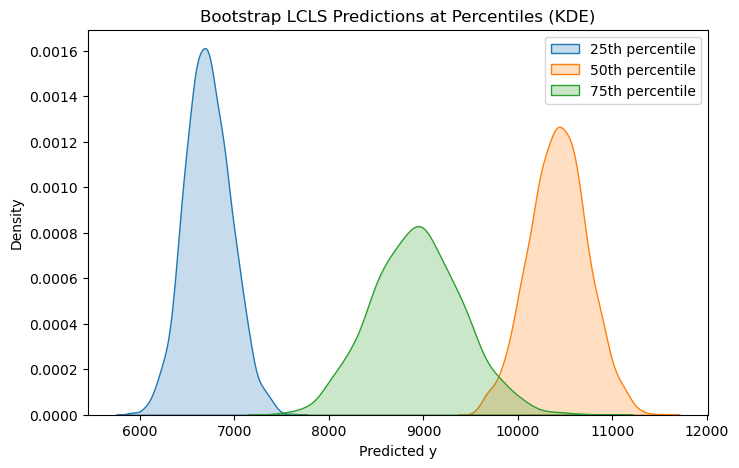

25th: median=6711.06, 5%=6341.92, 95%=7132.27
50th: median=10427.53, 5%=9916.49, 95%=10926.98
75th: median=8926.17, 5%=8156.49, 95%=9755.23


In [149]:
percentile_kdes = lcls_bootstrap_percentiles_kde(x, y, S=2000)


for name, est in percentile_kdes.items():
    median = np.nanmedian(est)
    ci5, ci95 = np.nanpercentile(est, [5,95])
    print(f"{name}: median={median:.2f}, 5%={ci5:.2f}, 95%={ci95:.2f}")


Computed bandwidth h: 1.1886046336919212


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_59849/1286096057.py:27: RuntimeWarning: All-NaN slice encountered
  y_median = np.nanmedian(y_boot, axis=0)


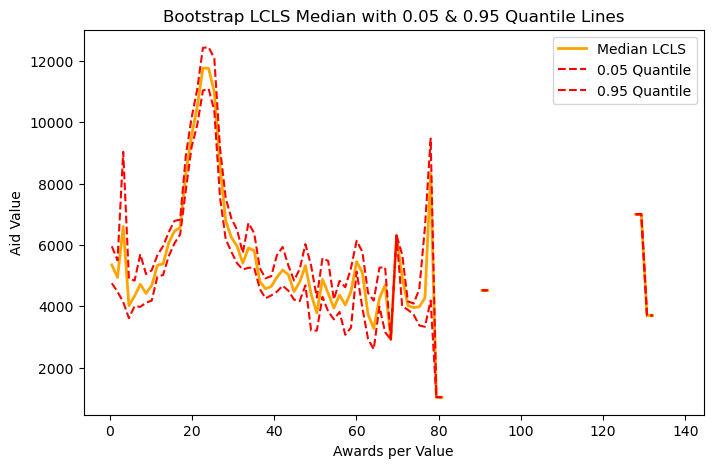

In [152]:
n = len(x)
iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
h = 0.9 * min(np.std(x), iqr / 1.34) * n**(-0.2)
print(f"Computed bandwidth h: {h}")


grid = np.linspace(x.min(), x.max(), 100)        

y_boot = np.zeros((30, len(grid)))

for s in range(30):
    idx = np.random.choice(n, n, replace=True)
    x_s = x.iloc[idx]
    y_s = y.iloc[idx]

    u = (grid.reshape(1,-1) - x_s.to_numpy().reshape(-1,1)) / h
    K = 0.75 * (1 - u**2) * (np.abs(u) <= 1)
    numerator = y_s.to_numpy() @ K
    denominator = np.sum(K, axis=0)
    y_boot[s,:] = np.divide(
        numerator, denominator,
        out=np.full_like(numerator, np.nan),
        where=denominator!=0
    )


y_median = np.nanmedian(y_boot, axis=0)
y_lower = np.nanpercentile(y_boot, 5, axis=0)
y_upper = np.nanpercentile(y_boot, 95, axis=0)


plt.figure(figsize=(8,5))
plt.plot(grid, y_median, color="orange", lw=2, label="Median LCLS")
plt.plot(grid, y_lower, 'r--', lw=1.5, label="0.05 Quantile")
plt.plot(grid, y_upper, 'r--', lw=1.5, label="0.95 Quantile")
plt.xlabel("Awards per Value")
plt.ylabel("Aid Value")
plt.title("Bootstrap LCLS Median with 0.05 & 0.95 Quantile Lines")
plt.legend()
plt.show()




*The predictions are tight/reliable more towards the center of the x axis, while predictions are more unreliable towards the ends of the x axis. The gaps in the line show missing data for that range, which definitely indicates unreliable predictions, specifically in the 80-120 range on the x axis.*

### Exercise 5
- Extend the `kde` class by adding a method to do bandwidth selection using a simple train-test split
- Extend the `kde` class by adding a method to do bandwidth seleciton by $k$-fold cross validation

### Exercise 6
In this exercise, you're going to do for LCLS what we just did for KDE: Pick the bandwidth 

Recall, the LCLS estimator is
$$
\hat{y}_{N,h}(z) = \dfrac{\frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left(\frac{z-x_i}{h}\right)}{\frac{1}{N} \sum_{i=1}^N \frac{1}{h}k\left(\frac{z-x_i}{h} \right)}.
$$
- Select two numeric variables from a data set. Split the data into training and test sets.
- Write a `predict(X_{train},Y_{train},X_{train})` function/method that takes a set of values $X_{test}$ and data $(X_{train},Y_{train})$, and computed predicted values $\hat{y}(X_{test})$ 
- Write a function/method that selects the bandwidth by **minimizing** the **mean squared error** of the squared differences between $\hat{y}(x_j)$ and $y_j$ on the test set:
$$
MSE(h) = \frac{1}{N_{test}} \sum_{j=1}^{N_{test}} (y_j - \hat{y}_{N_{train},h}(x_j))^2
$$
Be sure you understand what's happening here: The training data are used to make predictions for each test observation $x_j$, and then the prediction $\hat{y}(x_j)$ and true value $y_j$ are compared using squared difference